In [1]:
!nvidia-smi

Fri Jan 23 14:01:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
%pip install --upgrade ultralytics supervision roboflow onnx onnx2tf
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 39.5/112.6 GB disk)


In [5]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg
image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 88.4ms
Speed: 2.6ms preprocess, 88.4ms inference, 18.3ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict2
💡 Learn more at https://docs.ultralytics.com/modes/predict


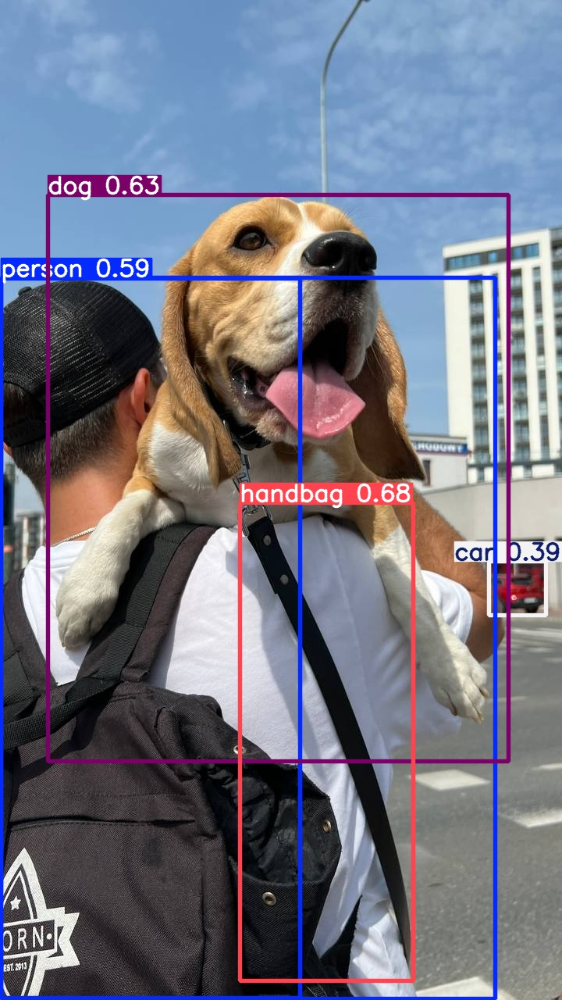

In [6]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

In [7]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 89.4ms
Speed: 3.1ms preprocess, 89.4ms inference, 18.5ms postprocess per image at shape (1, 3, 640, 384)


In [8]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4340e+02, 5.2918e+02, 1.2559e+03],
        [6.1387e+01, 2.4994e+02, 6.5166e+02, 9.7414e+02],
        [1.7901e+00, 3.5551e+02, 6.3408e+02, 1.2788e+03],
        [1.1987e+00, 3.5620e+02, 3.8467e+02, 1.2776e+03],
        [6.2617e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [9]:
result.boxes.conf

tensor([0.6828, 0.6284, 0.5945, 0.3926, 0.3867], device='cuda:0')

In [10]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

In [11]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

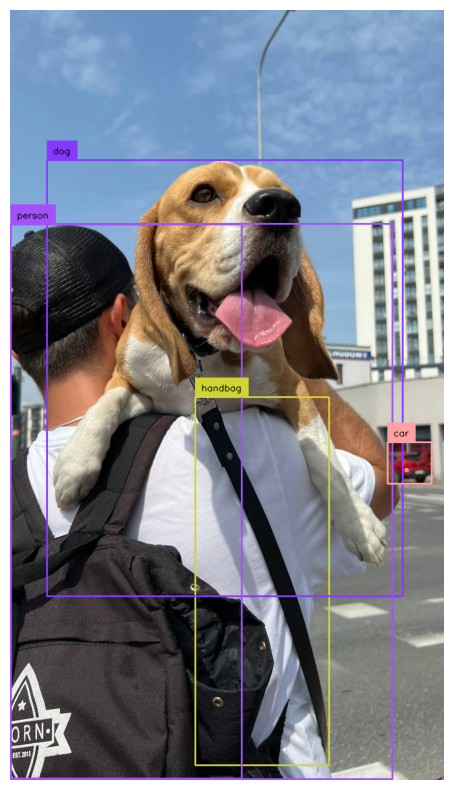

In [12]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [13]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(6) # version of dataset in roboflow
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-6 in yolov11:: 100%|██████████| 36780/36780 [00:04<00:00, 8160.17it/s]


In [14]:
%cd {HOME}

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=50 imgsz=640 plots=True # previous epoch: 10

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml \
# epochs=50 imgsz=640 batch=16 lr0=0.003 lrf=0.01 optimizer=AdamW \
# momentum=0.937 weight_decay=0.0005 warmup_epochs=5 \
# freeze=0 patience=30 cos_lr=True \
# box=7.5 cls=1.0 dfl=1.5 \
# hsv_h=0.015 hsv_s=0.7 hsv_v=0.4 mosaic=1.0 mixup=0.1 fliplr=0.5 \
# plots=True

!yolo task=detect mode=train model=yolo11s.pt \
data={dataset.location}/data.yaml \
epochs=150 imgsz=640 batch=32 \
lr0=0.003 lrf=0.01 optimizer=AdamW \
momentum=0.937 weight_decay=0.0005 \
warmup_epochs=3 \
freeze=0 \
patience=30 cos_lr=True \
mosaic=1.0 mixup=0.05 fliplr=0.5 \
hsv_h=0.015 hsv_s=0.5 hsv_v=0.4 \
plots=True


/content
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/datasets/erotica-detection-6/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, p

In [15]:
%load_ext tensorboard
%tensorboard --logdir /content/runs/detect

<IPython.core.display.Javascript object>

In [16]:
!ls {HOME}/runs/detect/train/

args.yaml			 labels.jpg		val_batch0_pred.jpg
BoxF1_curve.png			 results.csv		val_batch1_labels.jpg
BoxP_curve.png			 results.png		val_batch1_pred.jpg
BoxPR_curve.png			 train_batch0.jpg	val_batch2_labels.jpg
BoxR_curve.png			 train_batch1.jpg	val_batch2_pred.jpg
confusion_matrix_normalized.png  train_batch2.jpg	weights
confusion_matrix.png		 val_batch0_labels.jpg


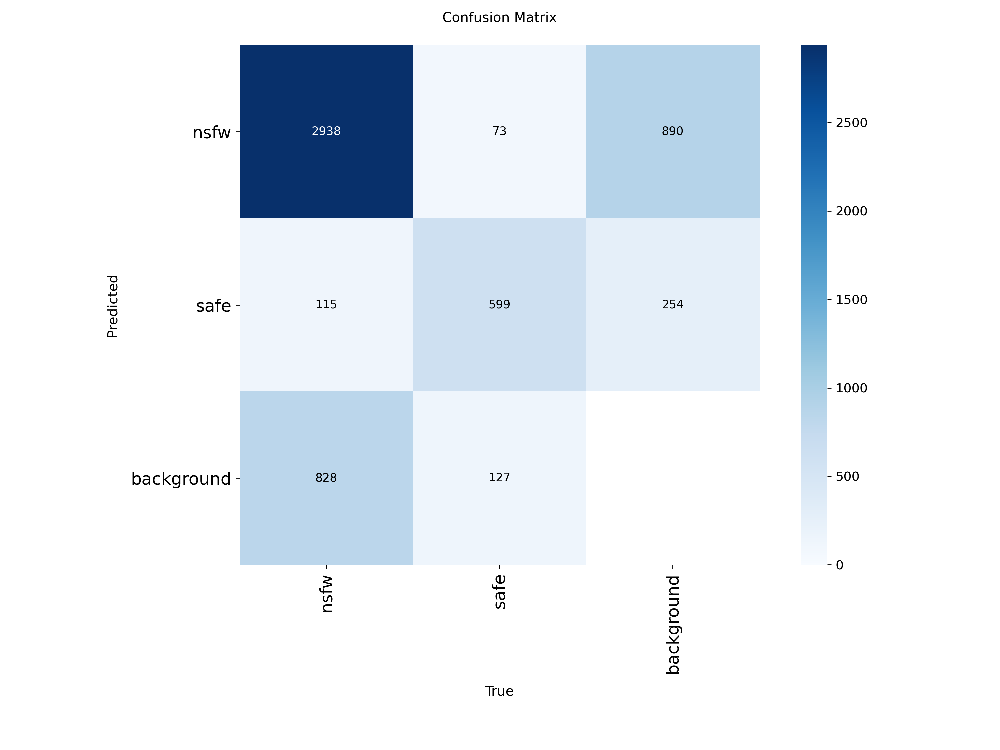

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

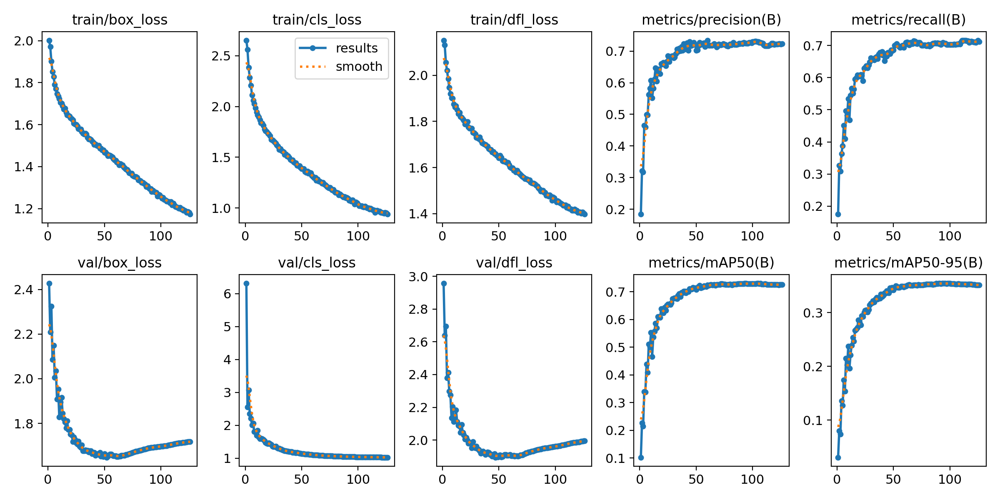

In [18]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

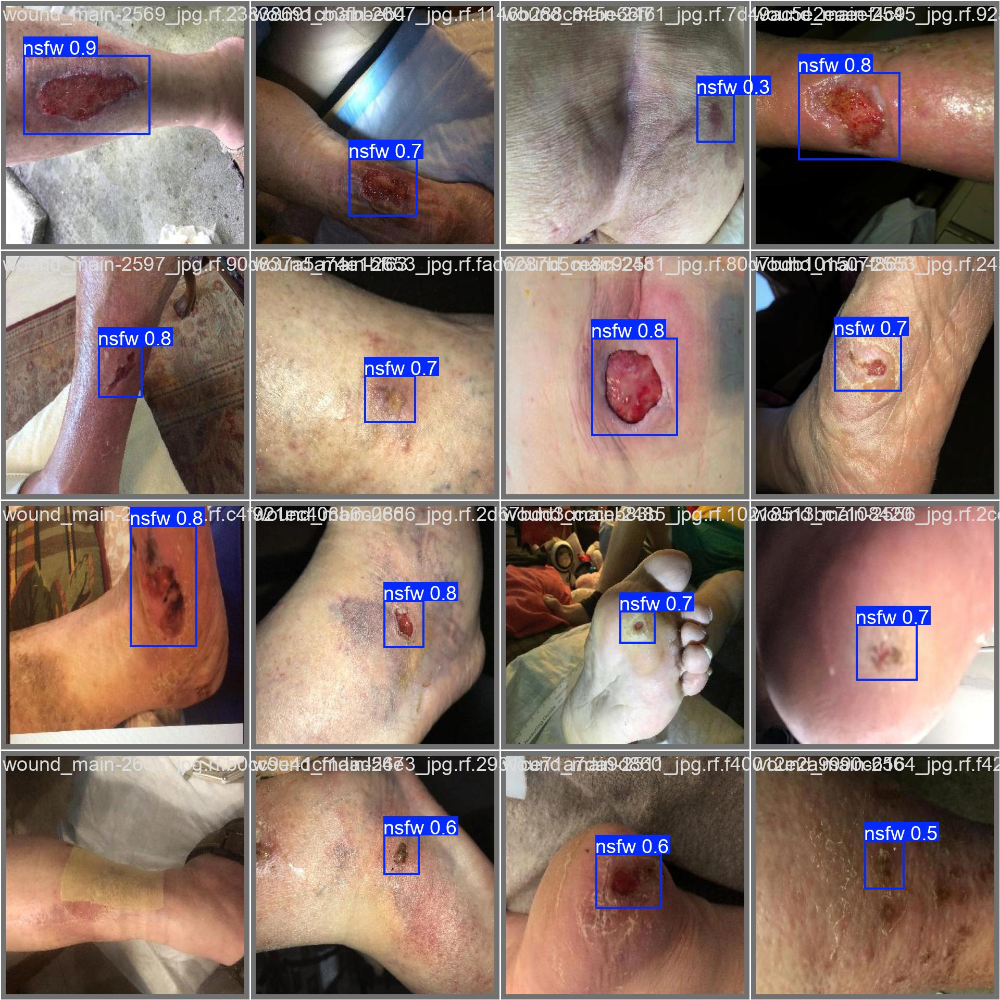

In [19]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [20]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1734.5±614.2 MB/s, size: 44.9 KB)
val: Scanning /content/datasets/erotica-detection-6/valid/labels.cache... 2816 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2816/2816 492.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 176/176 12.2it/s 14.4s
                   all       2816       4680      0.725      0.708      0.729      0.354
                  nsfw       2391       3881      0.797      0.717      0.778      0.407
                  safe        530        799      0.654      0.698       0.68        0.3
Speed: 0.7ms preprocess, 1.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [21]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/2789 /content/datasets/erotica-detection-6/test/images/9Cloud-us_0000-978B3Ab05B7D2D1179E42B02C89Bd98875D1Bd38-01E2H07W3_jpg.rf.483ae9ea6d2062f5aa481e9a68a62e0b.jpg: 640x640 1 nsfw, 9.7ms
image 2/2789 /content/datasets/erotica-detection-6/test/images/9Cloud-us_0001-6-01G12Q6Djrcnq295Zx6Tpnwtaw1680X0_jpg.rf.995b9b530830e6bc81568fb67dc27eff.jpg: 640x640 2 nsfws, 9.4ms
image 3/2789 /content/datasets/erotica-detection-6/test/images/9Cloud-us_0001-84C8Ae754A0D794C6Bca-01Ehtc72168D6Z9X38P0S8K5Tb64_jpg.rf.d6442a1d7cc6029e4d93dc0d34f42b06.jpg: 640x640 1 nsfw, 8.6ms
image 4/2789 /content/datasets/erotica-detection-6/test/images/9Cloud-us_0009-79583633-P0-Master12-01G5Hz94Szvvv0K3Zj2Jr7Cbn664_jpg.rf.48b8208fa9e65bab5cb2a177ac12d196.jpg: 640x640 1 nsfw, 1 safe, 8.6ms
image 5/2789 /content/datasets/erotica-detecti

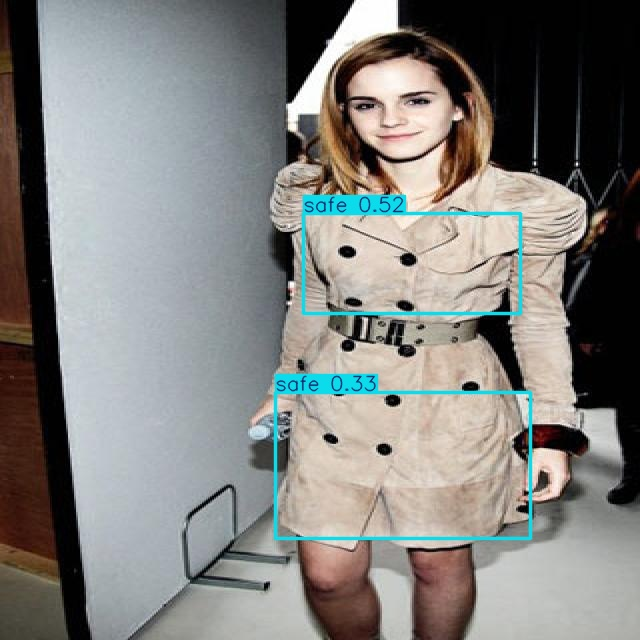

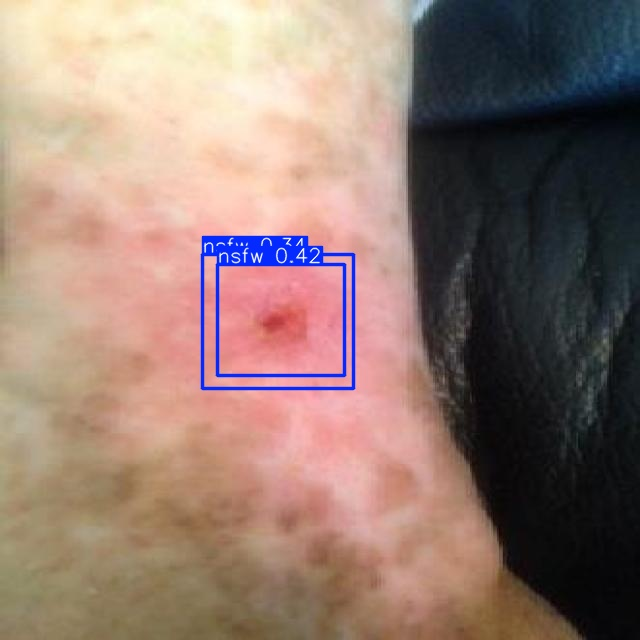

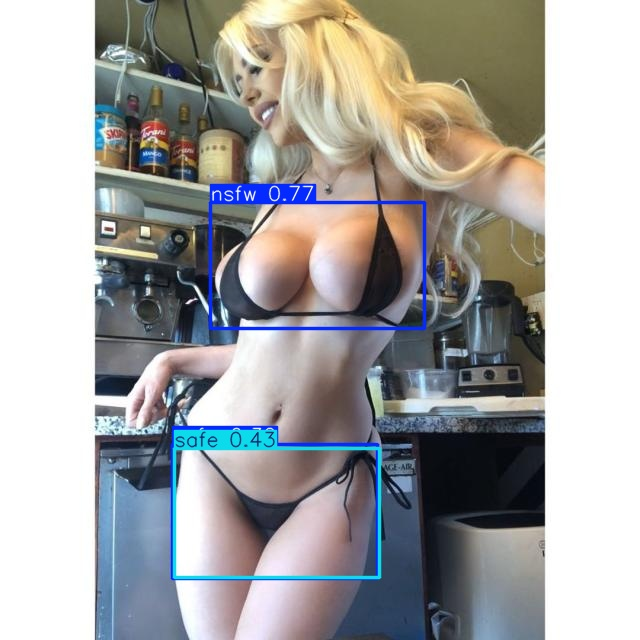

In [25]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [24]:
# model.export(format="tflite")

# # Zip the results and weights folder
# !zip -r yolov11n_results.zip /content/runs/detect/train/

# # Zip the saved models folder
# !zip -r yolov11n_saved_model.zip /content/yolo11n_saved_model

# from google.colab import files

# files.download('yolov11n_results.zip')
# files.download('yolov11n_saved_model.zip')

Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...

ONNX: starting export with onnx 1.19.0 opset 22...
ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 1.2s, saved as 'yolo11n.onnx' (10.3 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.29.0...
Saved artifact at 'yolo11n_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 84, 8400), dtype=tf.float32, name=None)
Captures:
  138889479561744: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  138889479563664: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  138889479561936: TensorSpec(shape=(16,), dtype=tf.float32, na

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>